In [22]:
# Clear all variables and import libraries
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
from scipy.interpolate import griddata
import re
import os
from math import ceil


In [23]:
# Configuration - Update these paths to your data folders
exp_folder = '../40/exp/40_degree_jet_02/Pos1'
sim_folder = '../40/sim/40_degree_jet_02/Laminar_steady_data/Pos3'
folder_name = '40_starccm_2L'
output_dir = '../Plots/'+ folder_name

z_velocity_offset = 0.00  # Constant term to add to simulation Z-velocity [m/s]
# Define distance steps from bottom (in meters)
distance_step = 0.002  # 2 mm steps
max_distance = 0.009   # Up to 10 mm from bottom

FLIP_LAYERS = 1
TRIM_TO_COMMON_X_RANGE = 1

In [24]:
# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load all CSV files
exp_files = glob.glob(f"{exp_folder}/*.csv")
sim_files = glob.glob(f"{sim_folder}/*.csv")

exp_files.sort()
sim_files.sort()
exp_files = exp_files[::-1]  # Reverse to match layer order
sim_files = sim_files[::-1]

print(f"Found {len(exp_files)} experimental files")
print(f"Found {len(sim_files)} simulation files")

# Load dataframes
exp_dataframes = [pd.read_csv(file) for file in exp_files]
sim_dataframes = [pd.read_csv(file) for file in sim_files]

# Extract file names for layer labels
exp_file_names = [os.path.basename(file) for file in exp_files]
sim_file_names = [os.path.basename(file) for file in sim_files]

print(f"\nExperimental files: {exp_file_names}")
print(f"Simulation files: {sim_file_names}")

# Auto-detect position and Reynolds number from first filename
# Try experimental files first, then simulation files
test_filename = exp_file_names[0] if len(exp_file_names) > 0 else sim_file_names[0]

# Extract position
pos_match = re.search(r'Pos(\d+)', test_filename)
if pos_match:
    position = int(pos_match.group(1))
    print(f"Automatically detected Position: {position}")
else:
    position = 1  # Default fallback
    print(f"Could not detect position from filename, using default: {position}")

# Extract Reynolds number
re_match = re.search(r'Re(\d+)', test_filename)
if re_match:
    Re_p = int(re_match.group(1))
    print(f"Automatically detected Re_p: {Re_p}")
else:
    Re_p = 100  # Default fallback
    print(f"Could not detect Re_p from filename, using default: {Re_p}")

Found 6 experimental files
Found 3 simulation files

Experimental files: ['L17_Pos01_Re0100_Jet02_0001_T.csv', 'L16_Pos01_Re0100_Jet02_0001_T.csv', 'L15_Pos01_Re0100_Jet02_0001_T.csv', 'L14_Pos01_Re0100_Jet02_0001_T.csv', 'L13_Pos01_Re0100_Jet02_0001_T.csv', 'L11_Pos01_Re0100_Jet02_0001_T.csv']
Simulation files: ['L13_Pos03_Re100_B0001_T.csv', 'L12_Pos03_Re100_B0001_T.csv', 'L11_Pos03_Re100_B0001_T.csv']
Automatically detected Position: 1
Automatically detected Re_p: 100


In [25]:
# Print column names for all experimental and simulation files
print("Experimental files and their columns:")
for fname, df in zip(exp_file_names, exp_dataframes):
    print(f"\n{fname}:")
    print(list(df.columns))

print("\nSimulation files and their columns:")
for fname, df in zip(sim_file_names, sim_dataframes):
    print(f"\n{fname}:")
    print(list(df.columns))

Experimental files and their columns:

L17_Pos01_Re0100_Jet02_0001_T.csv:
['x', 'y', 'z', 'Vel_u', 'Vel_v', 'Vel_w', 'Vel_mag', 'Stand_dev_Vx', 'Stand_dev_Vy', 'Stand_dev_Vz', 'Numb_of_vectors', 'isValid']

L16_Pos01_Re0100_Jet02_0001_T.csv:
['x', 'y', 'z', 'Vel_u', 'Vel_v', 'Vel_w', 'Vel_mag', 'Stand_dev_Vx', 'Stand_dev_Vy', 'Stand_dev_Vz', 'Numb_of_vectors', 'isValid']

L15_Pos01_Re0100_Jet02_0001_T.csv:
['x', 'y', 'z', 'Vel_u', 'Vel_v', 'Vel_w', 'Vel_mag', 'Stand_dev_Vx', 'Stand_dev_Vy', 'Stand_dev_Vz', 'Numb_of_vectors', 'isValid']

L14_Pos01_Re0100_Jet02_0001_T.csv:
['x', 'y', 'z', 'Vel_u', 'Vel_v', 'Vel_w', 'Vel_mag', 'Stand_dev_Vx', 'Stand_dev_Vy', 'Stand_dev_Vz', 'Numb_of_vectors', 'isValid']

L13_Pos01_Re0100_Jet02_0001_T.csv:
['x', 'y', 'z', 'Vel_u', 'Vel_v', 'Vel_w', 'Vel_mag', 'Stand_dev_Vx', 'Stand_dev_Vy', 'Stand_dev_Vz', 'Numb_of_vectors', 'isValid']

L11_Pos01_Re0100_Jet02_0001_T.csv:
['x', 'y', 'z', 'Vel_u', 'Vel_v', 'Vel_w', 'Vel_mag', 'Stand_dev_Vx', 'Stand_dev_Vy', 

In [26]:
# Plot parameters
n_grid = 500      # Grid resolution for contour
n_arrows = 14    # Number of arrows for streamplot

# Column name mappings
# Experimental data uses these column names
exp_x_col = 'x'
exp_z_col = 'z'
exp_u_col = 'Vel_u'
exp_w_col = 'Vel_w'

# Simulation data uses these column names
sim_x_col = 'x'
sim_z_col = 'z'
sim_u_col = 'Vel_u'
sim_w_col = 'Vel_w'

print(f"Grid resolution: {n_grid}")
print(f"Streamplot arrows: {n_arrows}")

# Apply z_velocity_offset to simulation data and calculate velocity magnitudes
print("Applying z_velocity_offset to simulation data...")
for df_sim in sim_dataframes:
    df_sim[sim_w_col] = df_sim[sim_w_col] + z_velocity_offset

print("Calculating velocity magnitudes...")

all_vel_mag_values = []

# Calculate for experimental data
for df_exp in exp_dataframes:
    df_exp['vel_magnitude'] = np.sqrt(df_exp[exp_u_col]**2 + df_exp[exp_w_col]**2)
    all_vel_mag_values.extend(df_exp['vel_magnitude'].values)

# Calculate for simulation data (with offset already applied)
for df_sim in sim_dataframes:
    df_sim['vel_magnitude'] = np.sqrt(df_sim[sim_u_col]**2 + df_sim[sim_w_col]**2)
    all_vel_mag_values.extend(df_sim['vel_magnitude'].values)

# Calculate common colorbar limits from all data
all_vel_mag_values = np.array(all_vel_mag_values)
all_vel_mag_values = all_vel_mag_values[np.isfinite(all_vel_mag_values)]  # Remove NaN and inf

common_vmin = all_vel_mag_values.min()
common_vmax = all_vel_mag_values.max()

print(f"\nCalculated velocity magnitude range from all data:")
print(f"  Min: {common_vmin:.6f} m/s")
print(f"  Max: {common_vmax:.6f} m/s")

levels = np.linspace(common_vmin, common_vmax, 50)

####
# Line plots at specific vertical distances (Z-heights)
# Show all simulation layers + middle experimental layer with std deviation

# Determine z-range for line plots (use experimental data range)
z_min_exp = float(min(df[exp_z_col].min() for df in exp_dataframes))
z_max_exp = float(max(df[exp_z_col].max() for df in exp_dataframes))

Grid resolution: 500
Streamplot arrows: 14
Applying z_velocity_offset to simulation data...
Calculating velocity magnitudes...

Calculated velocity magnitude range from all data:
  Min: 0.000000 m/s
  Max: 5.406508 m/s


In [27]:
# TRIM DATA TO COMMON X-AXIS RANGE
# ============================================================
# This ensures all layers use the same x-axis range for better comparison

if TRIM_TO_COMMON_X_RANGE:
    print("\n" + "=" * 80)
    print("TRIMMING DATA TO COMMON X-AXIS RANGE")
    print("=" * 80)
    
    # Find the common x-range (intersection of all layers)
    # This is the range where ALL layers have data
    
    # Find max of all minimums (most restrictive lower bound)
    x_min_common = max(
        max(df[exp_x_col].min() for df in exp_dataframes),
        max(df[sim_x_col].min() for df in sim_dataframes)
    )
    
    # Find min of all maximums (most restrictive upper bound)
    x_max_common = min(
        min(df[exp_x_col].max() for df in exp_dataframes),
        min(df[sim_x_col].max() for df in sim_dataframes)
    )
    
    print(f"\nCommon X-axis range: [{x_min_common:.6f}, {x_max_common:.6f}] m")
    print(f"Range width: {(x_max_common - x_min_common)*1000:.2f} mm\n")
    
    # Trim EXPERIMENTAL layers
    trimmed_exp_counts = []
    for i, (df, filename) in enumerate(zip(exp_dataframes, exp_file_names)):
        original_count = len(df)
        
        # Filter to common x-range
        mask = (df[exp_x_col] >= x_min_common) & (df[exp_x_col] <= x_max_common)
        df_trimmed = df[mask].copy()
        
        # Replace the dataframe in the list
        exp_dataframes[i] = df_trimmed
        
        trimmed_count = original_count - len(df_trimmed)
        trimmed_exp_counts.append(trimmed_count)
        
        # Extract layer info
        layer_match = re.search(r'L(\d{2})', filename)
        layer_id = f"L{layer_match.group(1)}" if layer_match else f"Layer {i+1}"
        
        print(f"EXP {layer_id}: {original_count} → {len(df_trimmed)} points (removed {trimmed_count})")
    
    print()
    
    # Trim SIMULATION layers
    trimmed_sim_counts = []
    for i, (df, filename) in enumerate(zip(sim_dataframes, sim_file_names)):
        original_count = len(df)
        
        # Filter to common x-range
        mask = (df[sim_x_col] >= x_min_common) & (df[sim_x_col] <= x_max_common)
        df_trimmed = df[mask].copy()
        
        # Replace the dataframe in the list
        sim_dataframes[i] = df_trimmed
        
        trimmed_count = original_count - len(df_trimmed)
        trimmed_sim_counts.append(trimmed_count)
        
        # Extract layer info
        layer_match = re.search(r'L(\d{2})', filename)
        layer_id = f"L{layer_match.group(1)}" if layer_match else f"Layer {i+1}"
        
        print(f"SIM {layer_id}: {original_count} → {len(df_trimmed)} points (removed {trimmed_count})")
    
    total_trimmed = sum(trimmed_exp_counts) + sum(trimmed_sim_counts)
    
    print("\n" + "=" * 80)
    print(f"Trimming complete! Removed {total_trimmed} total points")
    print(f"All layers now span X ∈ [{x_min_common:.6f}, {x_max_common:.6f}] m")
    print("=" * 80 + "\n")
    
else:
    print("\n" + "-" * 80)
    print("X-axis trimming is DISABLED")
    print("Set TRIM_TO_COMMON_X_RANGE = True to trim all layers to common X range")
    print("-" * 80 + "\n")


TRIMMING DATA TO COMMON X-AXIS RANGE

Common X-axis range: [0.987471, -0.018529] m
Range width: -1006.00 mm

EXP L17: 5312 → 0 points (removed 5312)
EXP L16: 5644 → 0 points (removed 5644)
EXP L15: 5445 → 0 points (removed 5445)
EXP L14: 5712 → 0 points (removed 5712)
EXP L13: 6012 → 0 points (removed 6012)
EXP L11: 5712 → 0 points (removed 5712)

SIM L13: 820 → 0 points (removed 820)
SIM L12: 870 → 0 points (removed 870)
SIM L11: 915 → 0 points (removed 915)

Trimming complete! Removed 36442 total points
All layers now span X ∈ [0.987471, -0.018529] m



ValueError: zero-size array to reduction operation minimum which has no identity

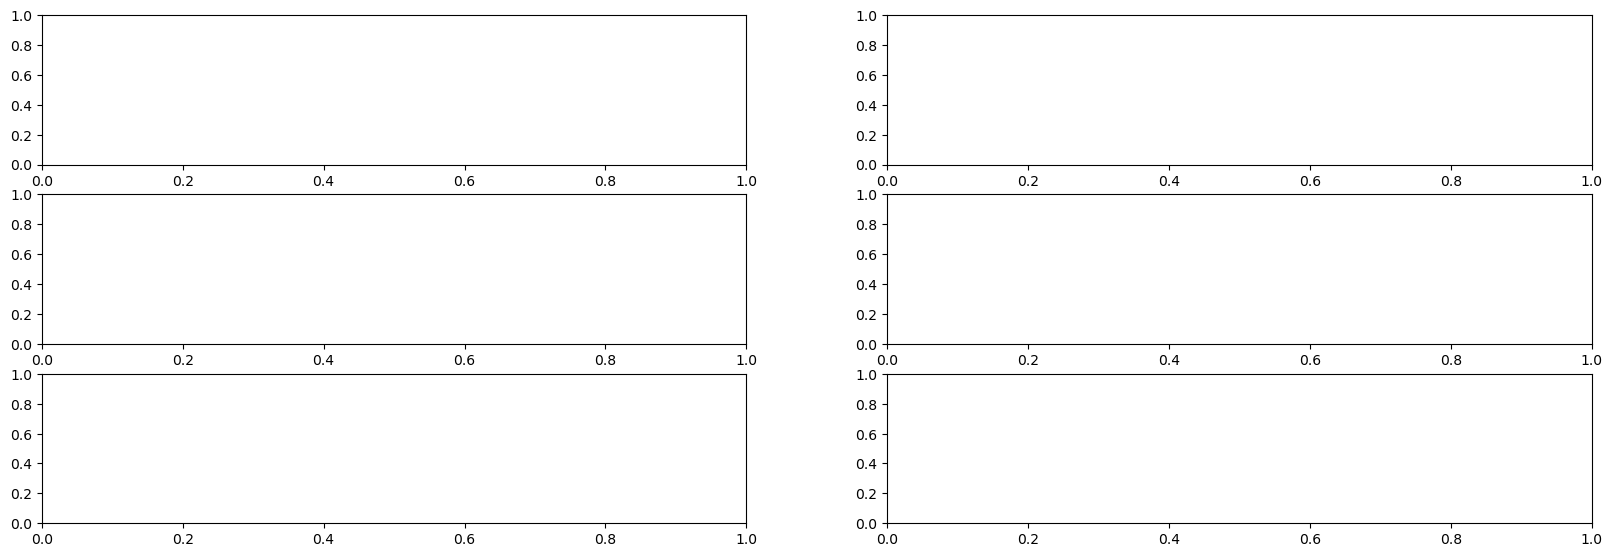

In [28]:
# Combined Exp–Sim comparison plot (publication-ready layout)
# ============================================================
n_layers = min(len(exp_dataframes), len(sim_dataframes))
fig, axes = plt.subplots(
    nrows=n_layers,
    ncols=2,
    figsize=(20, 2.2 * n_layers)   # ← wider figure
)

if n_layers == 1:
    axes = axes.reshape(1, -1)

# --- Global X-limits for alignment ---
x_min_global = min(df[exp_x_col].min() for df in exp_dataframes)
x_max_global = max(df[exp_x_col].max() for df in exp_dataframes)

# --- Shared color scale already defined: common_vmin, common_vmax ---

for i in range(n_layers):
    df_exp = exp_dataframes[i]
    df_sim = sim_dataframes[i]

    # ----- Layer label -----
    try:
        angle_deg = -np.degrees(df_exp['alpha'].iloc[0])
        layer_label = f"{angle_deg:.0f}°"
    except:
        # Fallback: extract layer id from filename (e.g. L17)
        fname = exp_file_names[i] if i < len(exp_file_names) else (sim_file_names[i] if i < len(sim_file_names) else None)
        layer_match = re.search(r'L(\d+)', fname) if fname else None
        layer_label = f"L{layer_match.group(1)}" if layer_match else f"Layer {i+1}"

    # ============================================================
    # ========== EXPERIMENT (LEFT COLUMN)
    # ============================================================
    ax_exp = axes[i, 0]

    x_exp = df_exp[exp_x_col].values
    z_exp = df_exp[exp_z_col].values
    u_exp = df_exp[exp_u_col].values
    w_exp = df_exp[exp_w_col].values
    vel_mag_exp = df_exp['vel_magnitude'].values

    xi = np.linspace(x_exp.min(), x_exp.max(), n_grid)
    zi = np.linspace(z_exp.min(), z_exp.max(), n_grid)
    Xi, Zi = np.meshgrid(xi, zi)

    points = np.column_stack((x_exp, z_exp))
    Ui = griddata(points, u_exp, (Xi, Zi), method='linear', fill_value=0)
    Wi = griddata(points, w_exp, (Xi, Zi), method='linear', fill_value=0)
    Vmag = griddata(points, vel_mag_exp, (Xi, Zi), method='linear', fill_value=0)

    mag = np.sqrt(Ui**2 + Wi**2)
    Ui_norm = np.zeros_like(Ui)
    Wi_norm = np.zeros_like(Wi)
    mask = mag > 1e-6
    Ui_norm[mask] = Ui[mask]/mag[mask]
    Wi_norm[mask] = Wi[mask]/mag[mask]

    contour_exp = ax_exp.contourf(
        Xi, Zi, Vmag,
        levels=levels, cmap='jet',
        vmin=common_vmin, vmax=common_vmax, extend='both'
    )
    ax_exp.streamplot(
        Xi, Zi, Ui_norm, Wi_norm,
        density=1.2, color='white',
        linewidth=1.1, arrowsize=1.0, arrowstyle='fancy'
    )

    # --- LOCAL Z-limits: each row shows only its slice ---
    ax_exp.set_ylim(z_exp.min(), z_exp.max())
    ax_exp.set_xlim(x_min_global, x_max_global)
    ax_exp.margins(y=0)

    ax_exp.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    ax_exp.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_exp.tick_params(axis='y', left=True, labelleft=True, labelsize=14)

    # ----- Row label -----
    ax_exp.annotate(
        layer_label, xy=(0.02, 0.50), xycoords='axes fraction',
        fontsize=16, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8)
    )

    # ============================================================
    # ========== SIMULATION (RIGHT COLUMN)
    # ============================================================
    ax_sim = axes[i, 1]

    x_sim = df_sim[sim_x_col].values
    z_sim = df_sim[sim_z_col].values
    u_sim = df_sim[sim_u_col].values
    w_sim = df_sim[sim_w_col].values
    vel_mag_sim = df_sim['vel_magnitude'].values

    xi = np.linspace(x_sim.min(), x_sim.max(), n_grid)
    zi = np.linspace(z_sim.min(), z_sim.max(), n_grid)
    Xi, Zi = np.meshgrid(xi, zi)

    points = np.column_stack((x_sim, z_sim))
    Ui = griddata(points, u_sim, (Xi, Zi), method='linear', fill_value=0)
    Wi = griddata(points, w_sim - z_velocity_offset, (Xi, Zi), method='linear', fill_value=0)
    Vmag = griddata(points, vel_mag_sim, (Xi, Zi), method='linear', fill_value=0)

    mag = np.sqrt(Ui**2 + Wi**2)
    Ui_norm = np.zeros_like(Ui)
    Wi_norm = np.zeros_like(Wi)
    mask = mag > 1e-6
    Ui_norm[mask] = Ui[mask]/mag[mask]
    Wi_norm[mask] = Wi[mask]/mag[mask]

    contour_sim = ax_sim.contourf(
        Xi, Zi, Vmag,
        levels=levels, cmap='jet',
        vmin=common_vmin, vmax=common_vmax, extend='both'
    )
    ax_sim.streamplot(
        Xi, Zi, Ui_norm, Wi_norm,
        density=1.2, color='white',
        linewidth=1.1, arrowsize=1.0, arrowstyle='fancy'
    )

    # --- LOCAL Z-limits ---
    ax_sim.set_ylim(z_sim.min(), z_sim.max())
    ax_sim.set_xlim(x_min_global, x_max_global)
    ax_sim.margins(y=0)

    ax_sim.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    ax_sim.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_sim.tick_params(axis='y', left=False, labelleft=False)

    # --- Column labels in boxed style ---
    if i == 0:
        ax_exp.text(
            0.5, 1.02, "Experiment", transform=ax_exp.transAxes,
            ha='center', va='bottom',
            fontsize=16, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.85)
        )

        ax_sim.text(
            0.5, 1.02, "Simulation", transform=ax_sim.transAxes,
            ha='center', va='bottom',
            fontsize=16, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.85)
        )

# ----- Bottom X labels -----
axes[-1, 0].tick_params(axis='x', bottom=True, labelbottom=True, labelsize=20)
axes[-1, 1].tick_params(axis='x', bottom=True, labelbottom=True, labelsize=20)
axes[-1, 0].set_xlabel('Projected X-position [m]', fontsize=20, fontweight='bold')
axes[-1, 1].set_xlabel('Projected X-position [m]', fontsize=20, fontweight='bold')

# ----- Middle Y label -----
mid = n_layers // 2
axes[mid, 0].set_ylabel('Z-position [m]', fontsize=20, fontweight='bold')
# ----- Layout: no vertical gaps -----
fig.subplots_adjust(
    right=0.86,
    hspace=0.0,
    wspace=0.08   # ← small gap between columns
)

# ----- Colorbar -----
cbar_ax = fig.add_axes([0.90, 0.12, 0.02, 0.75])
cbar = fig.colorbar(contour_exp, cax=cbar_ax)
cbar.set_label(
    'Velocity Magnitude |V| [m/s]',
    rotation=270,
    labelpad=28,
    fontsize=20, fontweight='bold'
)
cbar.ax.tick_params(labelsize=16)

# ----- Title -----
fig.suptitle(
    f'Experiment vs Simulation Comparison - Re$_p$ = {Re_p}, Position {position}',
    fontsize=30, fontweight='bold', y=0.985   # lower title → no extra gap
)

plt.savefig(f'{output_dir}/Combined_Exp_Sim_Pos{position}_Re{Re_p}.png',
            dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Line plots at specific distances from bottom of layer
# Show all simulation layers + experimental mean with std deviation

distances_from_bottom = np.arange(distance_step, max_distance + 1e-12, distance_step)

print(f"\nPlotting at distances from bottom (mm): {[d*1000 for d in distances_from_bottom]}")
print(f"Total number of plots: {len(distances_from_bottom)}")

# Determine subplot layout
n_plots = len(distances_from_bottom)
if n_plots <= 4:
    n_rows, n_cols = 2, 2
elif n_plots <= 6:
    n_rows, n_cols = 2, 3
elif n_plots <= 9:
    n_rows, n_cols = 3, 3
else:
    n_rows, n_cols = 3, 4

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

# Process each distance from bottom
for idx, distance in enumerate(distances_from_bottom):
    deci = 5  # Precision for filtering
    ax = axes[idx]
    
    # Plot all SIMULATION layers
    for i, df_sim in enumerate(sim_dataframes):
        # Calculate z-position for this layer (distance from its bottom)
        z_min_layer = df_sim[sim_z_col].min()
        z_target = z_min_layer + distance
        
        # Check if this distance exists in this layer
        if z_target <= df_sim[sim_z_col].max():
            # Find closest z-value in simulation data
            closest_z_sim = df_sim[sim_z_col].iloc[(df_sim[sim_z_col] - z_target).abs().argsort()[:1]].iloc[0]
            
            # Filter data at this Z-height
            df_sim_filtered = df_sim[abs(df_sim[sim_z_col] - closest_z_sim) < 10**(-deci)]
            
            if len(df_sim_filtered) > 0:
                df_sim_filtered = df_sim_filtered.sort_values(sim_x_col)
                
                # Extract layer label from filename
                sim_match = re.search(r'L(\d{2})', sim_file_names[i])
                layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
                
                # Plot simulation layer
                ax.plot(df_sim_filtered[sim_x_col], df_sim_filtered['vel_magnitude'], 
                       label=layer_label, linestyle='-', linewidth=2.0, alpha=0.8)
    
    # Calculate EXPERIMENTAL data statistics across all layers
    # Collect data from all experimental layers at this distance from bottom
    all_exp_data = []
    
    for i, df_exp in enumerate(exp_dataframes):
        # Calculate z-position for this layer (distance from its bottom)
        z_min_layer = df_exp[exp_z_col].min()
        z_target = z_min_layer + distance
        
        # Check if this distance exists in this layer
        if z_target <= df_exp[exp_z_col].max():
            # Find closest z-value in experimental data
            closest_z_exp = df_exp[exp_z_col].iloc[(df_exp[exp_z_col] - z_target).abs().argsort()[:1]].iloc[0]
            
            # Filter data at this Z-height
            df_exp_filtered = df_exp[abs(df_exp[exp_z_col] - closest_z_exp) < 10**(-deci)]
            
            if len(df_exp_filtered) > 0:
                df_exp_filtered = df_exp_filtered.sort_values(exp_x_col)
                all_exp_data.append(df_exp_filtered)
    
    # Calculate mean and std across all experimental layers
    if len(all_exp_data) > 0:
        # Get common x-range from all experimental data
        x_min_all = min([df[exp_x_col].min() for df in all_exp_data])
        x_max_all = max([df[exp_x_col].max() for df in all_exp_data])
        x_grid = np.linspace(x_min_all, x_max_all, 100)
        
        vel_matrix = []
        
        for df_exp_layer in all_exp_data:
            x_layer = df_exp_layer[exp_x_col].values
            vel_layer = df_exp_layer['vel_magnitude'].values
            
            # Interpolate to common grid
            from scipy.interpolate import interp1d
            if len(x_layer) > 1:
                f_interp = interp1d(x_layer, vel_layer, kind='linear', 
                                   bounds_error=False, fill_value=np.nan)
                vel_interp = f_interp(x_grid)
                vel_matrix.append(vel_interp)
        
        # Calculate mean and std across layers
        if len(vel_matrix) > 0:
            vel_matrix = np.array(vel_matrix)
            vel_mean = np.nanmean(vel_matrix, axis=0)
            vel_std = np.nanstd(vel_matrix, axis=0)
            
            # Plot experimental mean with std deviation
            ax.fill_between(x_grid, vel_mean - vel_std, vel_mean + vel_std,
                            color='#1e28f2', alpha=0.3, label='Exp ± std', zorder=1)
            ax.plot(x_grid, vel_mean, 'b-', label='Exp mean', 
                   linewidth=2.0, zorder=3)
    
    # Configure subplot
    ax.set_xlabel('X [m]', fontsize=20, fontweight='bold')
    ax.set_ylabel('|V| [m/s]', fontsize=20, fontweight='bold')
    ax.set_title(f'{distance*1000:.0f} mm from Bottom', fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
    ax.tick_params(axis='both', labelsize=20)

# Hide unused subplots
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

# Create single legend at the bottom for all subplots
# Get handles and labels from the first subplot (they're all the same)
handles, labels = axes[0].get_legend_handles_labels()

# Place legend below all subplots in a single row
ncol = ceil(len(labels) / 2)
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.02),
           ncol=ncol,  # arrange into 2 rows
           fontsize=18,
           frameon=True,
           fancybox=True,
           shadow=True)

# Add overall title
fig.suptitle(f'Velocity Profiles at Different Distances \nfrom Bottom (Re$_p$ = {Re_p}, Position {position})', 
            fontsize=26, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# Save plot
plot_filename = f'{output_dir}/Line_Profiles_from_Bottom_Pos{position}_Re{Re_p}.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nSaved: {plot_filename}")

plt.show()

print("\n" + "="*80)

In [ ]:
# Create maximum velocity comparison table - both per-layer and combined
print("\n" + "=" * 80)
print("MAXIMUM VELOCITY COMPARISON - PER LAYER")
print("=" * 80)

# Store per-layer comparisons
layer_comparisons = []

n_layers = min(len(exp_dataframes), len(sim_dataframes))

for i in range(n_layers):
    df_exp = exp_dataframes[i]
    df_sim = sim_dataframes[i]
    
    # Extract layer label
    exp_match = re.search(r'L(\d{2})', exp_file_names[i])
    layer_name = f"L{exp_match.group(1)}" if exp_match else f"Layer {i+1}"
    
    # Try to get angle from alpha column
    try:
        angle_deg = -np.degrees(df_exp['alpha'].iloc[0])
        layer_name = f"{angle_deg:.0f}°"
    except:
        pass
    
    # Get max velocities for this layer
    exp_u_max = df_exp[exp_u_col].max()
    exp_w_max = df_exp[exp_w_col].max()
    exp_mag_max = df_exp['vel_magnitude'].max()
    
    sim_u_max = df_sim[sim_u_col].max()
    sim_w_max = df_sim[sim_w_col].max()
    sim_mag_max = df_sim['vel_magnitude'].max()
    
    # Store for each velocity component
    layer_comparisons.append({
        'Layer': layer_name,
        'Component': 'X-vel (u)',
        'Exp [m/s]': exp_u_max,
        'Sim [m/s]': sim_u_max,
        'Diff [m/s]': sim_u_max - exp_u_max,
        'Rel Diff [%]': ((sim_u_max - exp_u_max) / exp_u_max) * 100 if exp_u_max != 0 else 0
    })
    
    layer_comparisons.append({
        'Layer': layer_name,
        'Component': 'Z-vel (w)',
        'Exp [m/s]': exp_w_max,
        'Sim [m/s]': sim_w_max,
        'Diff [m/s]': sim_w_max - exp_w_max,
        'Rel Diff [%]': ((sim_w_max - exp_w_max) / exp_w_max) * 100 if exp_w_max != 0 else 0
    })
    
    layer_comparisons.append({
        'Layer': layer_name,
        'Component': 'Magnitude |V|',
        'Exp [m/s]': exp_mag_max,
        'Sim [m/s]': sim_mag_max,
        'Diff [m/s]': sim_mag_max - exp_mag_max,
        'Rel Diff [%]': ((sim_mag_max - exp_mag_max) / exp_mag_max) * 100 if exp_mag_max != 0 else 0
    })

# Create DataFrame for per-layer table
layer_comparison_df = pd.DataFrame(layer_comparisons)

# Format and display per-layer data
pd.options.display.float_format = '{:.6f}'.format
print("\n" + layer_comparison_df.to_string(index=False))

# Now create combined (all layers) comparison
print("\n" + "=" * 80)
print("MAXIMUM VELOCITY COMPARISON - ALL LAYERS COMBINED")
print("=" * 80)

# Collect all velocity components from all layers
all_exp_u = []
all_exp_w = []
all_exp_mag = []
all_sim_u = []
all_sim_w = []
all_sim_mag = []

for df_exp in exp_dataframes:
    all_exp_u.extend(df_exp[exp_u_col].values)
    all_exp_w.extend(df_exp[exp_w_col].values)
    all_exp_mag.extend(df_exp['vel_magnitude'].values)

for df_sim in sim_dataframes:
    all_sim_u.extend(df_sim[sim_u_col].values)
    all_sim_w.extend(df_sim[sim_w_col].values)
    all_sim_mag.extend(df_sim['vel_magnitude'].values)

# Convert to arrays for calculation
all_exp_u = np.array(all_exp_u)
all_exp_w = np.array(all_exp_w)
all_exp_mag = np.array(all_exp_mag)
all_sim_u = np.array(all_sim_u)
all_sim_w = np.array(all_sim_w)
all_sim_mag = np.array(all_sim_mag)

# Create DataFrame for combined table
velocity_comparison = pd.DataFrame({
    #'Component': ['X-velocity (u)', 'Z-velocity (w)', 'Total magnitude |V|'],
    'Component': ['Total magnitude |V|'],
    'Experiment [m/s]': [
    #    all_exp_u.max(),
    #    all_exp_w.max(),
        all_exp_mag.max()
    ],
    'Simulation [m/s]': [
    #    all_sim_u.max(),
    #    all_sim_w.max(),
        all_sim_mag.max()
    ]
})

# Calculate differences and percentage
velocity_comparison['Difference [m/s]'] = (
    velocity_comparison['Simulation [m/s]'] - velocity_comparison['Experiment [m/s]']
)
velocity_comparison['Relative Diff [%]'] = (
    (velocity_comparison['Difference [m/s]'] / velocity_comparison['Experiment [m/s]']) * 100
)

# Format and display combined data
print("\n" + velocity_comparison.to_string(index=False))
print("\n" + "=" * 80 + "\n")

# Reset display format
pd.reset_option('display.float_format')

In [ ]:
# Create summary DataFrame showing max velocities per layer
print("\n" + "="*80)
print("SUMMARY: Maximum Velocity Magnitude Per Layer")
print("="*80)

layer_names = []
layer_max_vel_exp = []
layer_max_vel_sim = []

n_layers = min(len(exp_dataframes), len(sim_dataframes))

for i in range(n_layers):
    df_exp = exp_dataframes[i]
    df_sim = sim_dataframes[i]
    
    # Extract layer label
    exp_match = re.search(r'L(\d{2})', exp_file_names[i])
    layer_name = f"L{exp_match.group(1)}" if exp_match else f"Layer {i+1}"
    
    # Try to get angle from alpha column
    try:
        angle_deg = -np.degrees(df_exp['alpha'].iloc[0])
        layer_name = f"{angle_deg:.0f}°"
    except:
        pass
    
    layer_names.append(layer_name)
    layer_max_vel_exp.append(df_exp['vel_magnitude'].max())
    layer_max_vel_sim.append(df_sim['vel_magnitude'].max())

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Layer': layer_names,
    'Max_Vel_Exp_m/s': layer_max_vel_exp,
    'Max_Vel_Sim_m/s': layer_max_vel_sim,
    'Difference_m/s': np.array(layer_max_vel_sim) - np.array(layer_max_vel_exp),
    'Rel_Diff_%': ((np.array(layer_max_vel_sim) - np.array(layer_max_vel_exp)) / np.array(layer_max_vel_exp)) * 100
})

# Format and display
pd.options.display.float_format = '{:.6f}'.format
print("\n" + summary_df.to_string(index=False))

# Calculate averages
avg_diff = summary_df['Difference_m/s'].mean()
avg_abs_diff = summary_df['Difference_m/s'].abs().mean()
avg_rel_diff = summary_df['Rel_Diff_%'].mean()

print(f"\nAverage Difference (Sim - Exp) [m/s]: {avg_diff:.6f}")
print(f"Average Absolute Difference [m/s]: {avg_abs_diff:.6f}")
print(f"Average Relative Difference [%]: {avg_rel_diff:.3f}")
print("="*80 + "\n")

# Reset display format
pd.reset_option('display.float_format')

# Create plot showing max velocity per layer
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(layer_names))
width = 0.35

ax.bar(x_positions - width/2, layer_max_vel_exp, width, label='Experiment', color='b', alpha=0.7)
ax.bar(x_positions + width/2, layer_max_vel_sim, width, label='Simulation', color='r', alpha=0.7)

ax.set_xlabel('Layer', fontsize=14, fontweight='bold')
ax.set_ylabel('Maximum |V| [m/s]', fontsize=14, fontweight='bold')
ax.set_title(f'Maximum Velocity per Layer (Re$_p$ = {Re_p}, Position {position})', fontsize=16, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels(layer_names)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(labelsize=12)
plt.tight_layout()

# Save summary
summary_filename = f'{output_dir}/Layer_Velocity_Summary_Pos{position}_Re{Re_p}.csv'
summary_df.to_csv(summary_filename, index=False)
print(f"Summary saved to: {summary_filename}")

# Save plot
plot_filename = f'{output_dir}/Max_Velocity_per_Layer_Bar_Pos{position}_Re{Re_p}.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_filename}")

plt.show()

In [ ]:
# Create summary DataFrame showing max velocities per layer
print("\n" + "="*80)
print("SUMMARY: Maximum Velocity Magnitude Per Layer")
print("="*80)

layer_names = []
layer_max_vel_exp = []
layer_max_vel_sim = []

n_layers = min(len(exp_dataframes), len(sim_dataframes))

for i in range(n_layers):
    df_exp = exp_dataframes[i]
    df_sim = sim_dataframes[i]
    
    # Extract layer label
    exp_match = re.search(r'L(\d{2})', exp_file_names[i])
    layer_name = f"L{exp_match.group(1)}" if exp_match else f"Layer {i+1}"
    
    # Try to get angle from alpha column
    try:
        angle_deg = -np.degrees(df_exp['alpha'].iloc[0])
        layer_name = f"{angle_deg:.0f}°"
    except:
        pass
    
    layer_names.append(layer_name)
    layer_max_vel_exp.append(df_exp['vel_magnitude'].max())
    layer_max_vel_sim.append(df_sim['vel_magnitude'].max())

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Layer': layer_names,
    'Max_Vel_Exp_m/s': layer_max_vel_exp,
    'Max_Vel_Sim_m/s': layer_max_vel_sim,
    'Difference_m/s': np.array(layer_max_vel_sim) - np.array(layer_max_vel_exp),
    'Rel_Diff_%': ((np.array(layer_max_vel_sim) - np.array(layer_max_vel_exp)) / np.array(layer_max_vel_exp)) * 100
})

# Format and display
pd.options.display.float_format = '{:.6f}'.format
print("\n" + summary_df.to_string(index=False))

# Calculate averages
avg_diff = summary_df['Difference_m/s'].mean()
avg_abs_diff = summary_df['Difference_m/s'].abs().mean()
avg_rel_diff = summary_df['Rel_Diff_%'].mean()

print(f"\nAverage Difference (Sim - Exp) [m/s]: {avg_diff:.6f}")
print(f"Average Absolute Difference [m/s]: {avg_abs_diff:.6f}")
print(f"Average Relative Difference [%]: {avg_rel_diff:.3f}")
print("="*80 + "\n")

# Reset display format
pd.reset_option('display.float_format')

# Create line plot showing max velocity per layer
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(layer_names))

ax.plot(x_positions, layer_max_vel_exp, 'bo-', label='Experiment', linewidth=2, markersize=8)
ax.plot(x_positions, layer_max_vel_sim, 'rs-', label='Simulation', linewidth=2, markersize=8)

ax.set_xlabel('Layer', fontsize=14, fontweight='bold')
ax.set_ylabel('Maximum |V| [m/s]', fontsize=14, fontweight='bold')
ax.set_title(f'Maximum Velocity per Layer (Re$_p$ = {Re_p}, Position {position})', fontsize=16, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels(layer_names)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=12)
plt.tight_layout()

# Save summary
summary_filename = f'{output_dir}/Layer_Velocity_Summary_Pos{position}_Re{Re_p}.csv'
summary_df.to_csv(summary_filename, index=False)
print(f"Summary saved to: {summary_filename}")

# Save plot
plot_filename = f'{output_dir}/Max_Velocity_per_Layer_Pos{position}_Re{Re_p}.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_filename}")

plt.show()

In [ ]:
# Scatter plots: Experiment vs Simulation velocity comparison
print("\n" + "="*80)
print("CREATING SCATTER PLOTS (EXP VS SIM)")
print("="*80)

from scipy import stats

n_layers = min(len(exp_dataframes), len(sim_dataframes))

# Determine subplot layout
if n_layers <= 4:
    n_rows, n_cols = 2, 2
elif n_layers <= 6:
    n_rows, n_cols = 2, 3
else:
    n_rows, n_cols = 3, 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

# Process each layer
for i in range(n_layers):
    df_exp = exp_dataframes[i]
    df_sim = sim_dataframes[i]
    ax = axes[i]
    
    # Extract layer label
    exp_match = re.search(r'L(\d{2})', exp_file_names[i])
    layer_name = f"L{exp_match.group(1)}" if exp_match else f"Layer {i+1}"
    
    try:
        angle_deg = -np.degrees(df_exp['alpha'].iloc[0])
        layer_name = f"{angle_deg:.0f}°"
    except:
        pass
    
    # Interpolate simulation data to experimental grid for comparison
    from scipy.interpolate import griddata
    
    # Get experimental points
    x_exp = df_exp[exp_x_col].values
    z_exp = df_exp[exp_z_col].values
    vel_exp = df_exp['vel_magnitude'].values
    
    # Get simulation data
    x_sim = df_sim[sim_x_col].values
    z_sim = df_sim[sim_z_col].values
    vel_sim = df_sim['vel_magnitude'].values
    
    # Interpolate simulation to experimental points
    points_sim = np.column_stack((x_sim, z_sim))
    vel_sim_interp = griddata(points_sim, vel_sim, (x_exp, z_exp), method='linear')
    
    # Remove NaN values
    valid_mask = ~np.isnan(vel_sim_interp)
    vel_exp_valid = vel_exp[valid_mask]
    vel_sim_valid = vel_sim_interp[valid_mask]
    
    if len(vel_exp_valid) > 0:
        # Calculate statistics
        r_squared = np.corrcoef(vel_exp_valid, vel_sim_valid)[0, 1]**2
        rmse = np.sqrt(np.mean((vel_sim_valid - vel_exp_valid)**2))
        
        # Create scatter plot
        ax.scatter(vel_exp_valid, vel_sim_valid, alpha=0.5, s=20, edgecolors='none')
        
        # Add perfect agreement line (y=x)
        min_val = min(vel_exp_valid.min(), vel_sim_valid.min())
        max_val = max(vel_exp_valid.max(), vel_sim_valid.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Agreement')
        
        # Add statistics text
        stats_text = f'R² = {r_squared:.3f}\nRMSE = {rmse:.4f} m/s'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
               fontsize=14, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Experiment |V| [m/s]', fontsize=16, fontweight='bold')
        ax.set_ylabel('Simulation |V| [m/s]', fontsize=16, fontweight='bold')
        ax.set_title(f'Layer {layer_name}', fontsize=18, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=14)
        ax.legend(fontsize=12, loc='lower right')
        
        # Equal aspect ratio for better visualization
        ax.set_aspect('equal', adjustable='box')

# Hide unused subplots
for i in range(n_layers, len(axes)):
    axes[i].set_visible(False)

fig.suptitle(f'Experiment vs Simulation Scatter Plots (Re$_p$ = {Re_p}, Position {position})', 
            fontsize=24, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save plot
scatter_filename = f'{output_dir}/Scatter_Exp_vs_Sim_Pos{position}_Re{Re_p}.png'
plt.savefig(scatter_filename, dpi=300, bbox_inches='tight')
print(f"\nSaved: {scatter_filename}")

plt.show()

print("="*80)

In [ ]:
# Spatial difference maps: (Simulation - Experiment)
print("\n" + "="*80)
print("CREATING SPATIAL DIFFERENCE MAPS")
print("="*80)

n_layers = min(len(exp_dataframes), len(sim_dataframes))

# Create figure with 2 columns: Absolute Difference and Percentage Error
fig, axes = plt.subplots(
    nrows=n_layers,
    ncols=2,
    figsize=(16, 2.8 * n_layers)
)

# Ensure axes is 2D array
if n_layers == 1:
    axes = axes.reshape(1, -1)

# Process each layer
for i in range(n_layers):
    df_exp = exp_dataframes[i]
    df_sim = sim_dataframes[i]
    
    # Extract layer label
    exp_match = re.search(r'L(\d{2})', exp_file_names[i])
    layer_name = f"L{exp_match.group(1)}" if exp_match else f"Layer {i+1}"
    
    try:
        angle_deg = -np.degrees(df_exp['alpha'].iloc[0])
        layer_name = f"{angle_deg:.0f}°"
    except:
        pass
    
    # Create common grid for interpolation
    x_exp = df_exp[exp_x_col].values
    z_exp = df_exp[exp_z_col].values
    vel_exp = df_exp['vel_magnitude'].values
    
    x_sim = df_sim[sim_x_col].values
    z_sim = df_sim[sim_z_col].values
    vel_sim = df_sim['vel_magnitude'].values
    
    # Create grid based on experimental data extent
    xi = np.linspace(x_exp.min(), x_exp.max(), n_grid)
    zi = np.linspace(z_exp.min(), z_exp.max(), n_grid)
    Xi, Zi = np.meshgrid(xi, zi)
    
    # Interpolate both datasets to common grid
    points_exp = np.column_stack((x_exp, z_exp))
    points_sim = np.column_stack((x_sim, z_sim))
    
    Vel_exp_interp = griddata(points_exp, vel_exp, (Xi, Zi), method='linear')
    Vel_sim_interp = griddata(points_sim, vel_sim, (Xi, Zi), method='linear')
    
    # Calculate differences
    Diff_abs = Vel_sim_interp - Vel_exp_interp  # Absolute difference
    Diff_pct = ((Vel_sim_interp - Vel_exp_interp) / Vel_exp_interp) * 100  # Percentage error
    
    # Replace inf values with NaN
    Diff_pct[~np.isfinite(Diff_pct)] = np.nan
    
    # ========== ABSOLUTE DIFFERENCE (Left) ==========
    ax_abs = axes[i, 0]
    
    # Calculate symmetric colorbar limits for diverging colormap
    abs_max = np.nanmax(np.abs(Diff_abs))
    abs_levels = np.linspace(-abs_max, abs_max, 50)
    
    contour_abs = ax_abs.contourf(Xi, Zi, Diff_abs, levels=abs_levels, 
                                   cmap='RdBu_r', extend='both')
    
    ax_abs.set_xlim(x_exp.min(), x_exp.max())
    ax_abs.set_ylim(z_exp.min(), z_exp.max())
    ax_abs.grid(True, linestyle='--', alpha=0.3, color='black', linewidth=0.5)
    ax_abs.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax_abs.tick_params(axis='y', which='both', left=True, labelleft=True, labelsize=16)
    
    # Add layer label
    ax_abs.annotate(layer_name, xy=(0.02, 0.50), xycoords='axes fraction',
                    fontsize=16, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9))
    
    # Column title on first row
    if i == 0:
        ax_abs.set_title('Absolute Difference (Sim - Exp)', fontsize=18, fontweight='bold', pad=10)
    
    # ========== PERCENTAGE ERROR (Right) ==========
    ax_pct = axes[i, 1]
    
    # Calculate symmetric colorbar limits for percentage
    pct_max = min(np.nanmax(np.abs(Diff_pct)), 100)  # Cap at 100%
    pct_levels = np.linspace(-pct_max, pct_max, 50)
    
    contour_pct = ax_pct.contourf(Xi, Zi, Diff_pct, levels=pct_levels, 
                                   cmap='RdBu_r', extend='both')
    
    ax_pct.set_xlim(x_exp.min(), x_exp.max())
    ax_pct.set_ylim(z_exp.min(), z_exp.max())
    ax_pct.grid(True, linestyle='--', alpha=0.3, color='black', linewidth=0.5)
    ax_pct.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax_pct.tick_params(axis='y', which='both', left=False, labelleft=False)
    
    # Column title on first row
    if i == 0:
        ax_pct.set_title('Percentage Error [(Sim-Exp)/Exp × 100%]', fontsize=18, fontweight='bold', pad=10)

# Show x-axis only on bottom plots
axes[-1, 0].tick_params(axis='x', which='both', bottom=True, labelbottom=True, labelsize=16)
axes[-1, 1].tick_params(axis='x', which='both', bottom=True, labelbottom=True, labelsize=16)
axes[-1, 0].set_xlabel('Projected X-position [m]', fontsize=18, fontweight='bold')
axes[-1, 1].set_xlabel('Projected X-position [m]', fontsize=18, fontweight='bold')

# Add y-axis label to middle left plot
middle_idx = n_layers // 2
axes[middle_idx, 0].set_ylabel('Z-position [m]', fontsize=18, fontweight='bold')

# Add colorbars
fig.subplots_adjust(right=0.90, hspace=0.08, wspace=0.08)

# Colorbar for absolute difference
cbar_ax1 = fig.add_axes([0.92, 0.55, 0.02, 0.35])
cbar1 = fig.colorbar(contour_abs, cax=cbar_ax1)
cbar1.set_label('Absolute Difference [m/s]', rotation=270, labelpad=25, fontsize=16, fontweight='bold')
cbar1.ax.tick_params(labelsize=14)

# Colorbar for percentage error
cbar_ax2 = fig.add_axes([0.92, 0.10, 0.02, 0.35])
cbar2 = fig.colorbar(contour_pct, cax=cbar_ax2)
cbar2.set_label('Percentage Error [%]', rotation=270, labelpad=25, fontsize=16, fontweight='bold')
cbar2.ax.tick_params(labelsize=14)

# Add overall title
fig.suptitle(f'Spatial Difference Maps: Simulation - Experiment (Re$_p$ = {Re_p}, Position {position})', 
             fontsize=24, fontweight='bold', y=0.98)

# Save figure
diff_map_filename = f'{output_dir}/Difference_Maps_Pos{position}_Re{Re_p}.png'
plt.savefig(diff_map_filename, dpi=300, bbox_inches='tight')
print(f"\nSaved: {diff_map_filename}")

plt.show()

print("="*80)